In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [4]:
from google.colab import files
upload = files.upload()

Saving crop_yield.csv to crop_yield.csv


In [5]:
df = pd.read_csv("crop_yield.csv")

In [6]:
print("First 5 rows:")
print(df.head())

First 5 rows:
  Fert Water  Yield
0    A  High   27.4
1    A  High   33.6
2    A  High   29.8
3    A  High   35.2
4    A  High   33.0


In [7]:
print("\nDataset Shape:")
print(df.shape)

print("\nDataset Information:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())


Dataset Shape:
(20, 3)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Fert    20 non-null     object 
 1   Water   20 non-null     object 
 2   Yield   20 non-null     float64
dtypes: float64(1), object(2)
memory usage: 612.0+ bytes
None

Statistical Summary:
           Yield
count  20.000000
mean   29.040000
std     4.230516
min    19.400000
25%    26.400000
50%    29.600000
75%    32.400000
max    35.200000


In [8]:
print("\nMissing Values:")
print(df.isnull().sum())

df = df.dropna()


Missing Values:
Fert     0
Water    0
Yield    0
dtype: int64


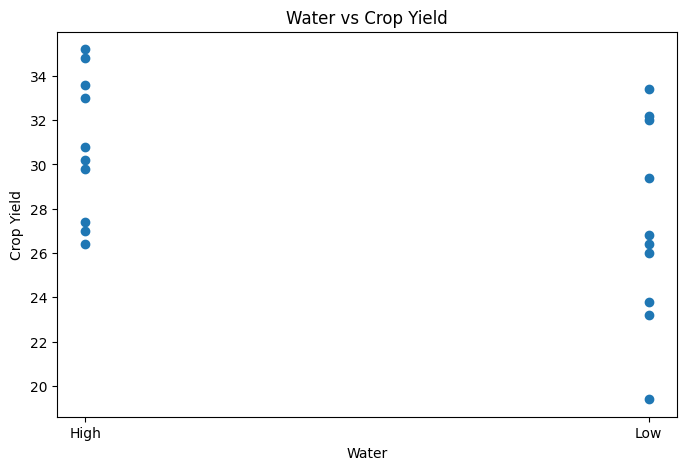

In [10]:
plt.figure(figsize=(8, 5))
plt.scatter(df["Water"], df["Yield"])
plt.xlabel("Water")
plt.ylabel("Crop Yield")
plt.title("Water vs Crop Yield")
plt.show()

In [11]:
X = df.drop("Yield", axis=1)
y = df["Yield"]

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [13]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [15]:
X = pd.get_dummies(X, columns=['Fert', 'Water'], drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model.fit(X_train, y_train)

print("\nModel training completed!")


Model training completed!


In [16]:
y_pred = model.predict(X_test)

print("\nActual Values:")
print(y_test.values)

print("\nPredicted Values:")
print(y_pred)


Actual Values:
[27.4 29.4 26.8 33.6]

Predicted Values:
[32.43650556 22.26953333 22.26953333 32.43650556]


In [17]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\nModel Performance")
print("-------------------------")
print("MAE :", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)



Model Performance
-------------------------
MAE : 4.465233333333331
RMSE: 4.951989262801796
R2 Score: -2.4587020675464406


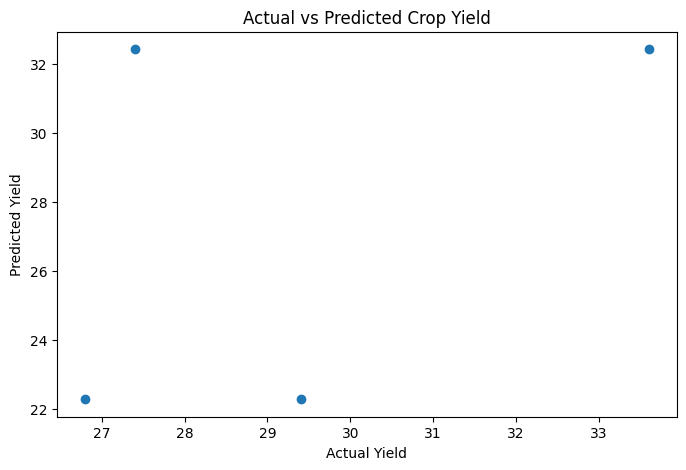

In [18]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("Actual vs Predicted Crop Yield")
plt.show()

In [19]:
importance = model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nFeature Importance:")
print(feature_importance)



Feature Importance:
     Feature  Importance
0     Fert_B    0.532181
1  Water_Low    0.467819


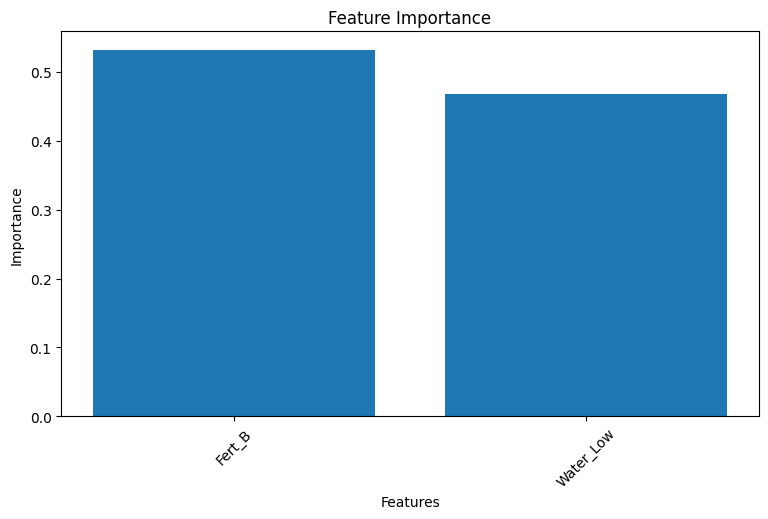

In [20]:
plt.figure(figsize=(9, 5))
plt.bar(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Feature Importance")
plt.xticks(rotation=45)
plt.show()


In [22]:
new_data = pd.DataFrame({
    "Fert_B": [0],  # Example: 'Fert' is 'A'
    "Water_Low": [0] # Example: 'Water' is 'High'
})

predicted_yield = model.predict(new_data)

print("\nPredicted Crop Yield:")
print(predicted_yield[0])


Predicted Crop Yield:
32.43650555555555
